This is the presentation of creating the number classifying from start to end with visualization

Shape of data (60000, 28, 28)
Shape of target (60000,)


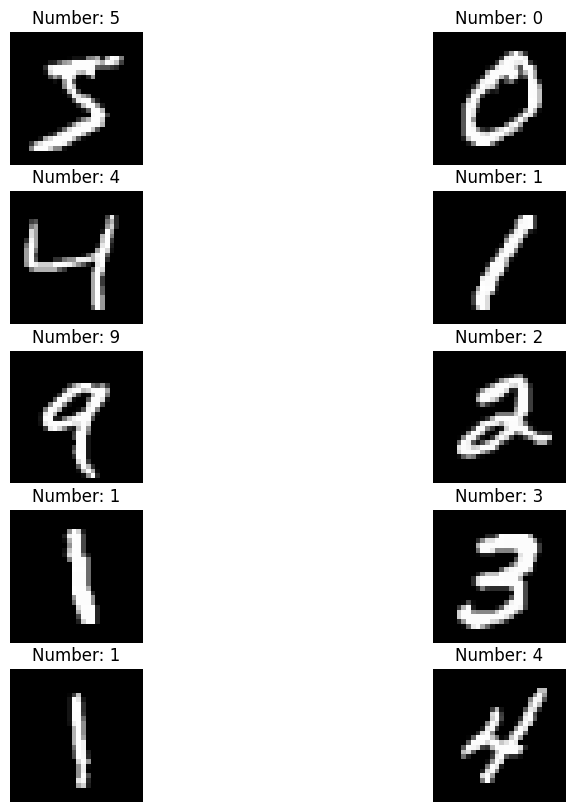

In [17]:
import numpy as np 
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers # type: ignore

# Load data into variable
data = np.load("data/mnist.npz") 

# Extract train, test, file
x_train, x_test, y_train, y_test = data["x_train"], data["x_test"], data["y_train"], data["y_test"]

# Convert integer labels to one-hot vectors for better loss function
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)

print("Shape of data", x_train.shape)
print("Shape of target", y_train.shape)

#Draw first 10 number in train to see
plt.figure(figsize=(10,10)) #width 10, height 10
for i in range(10):
    plt.subplot(5, 2, i + 1)
    plt.imshow(x_train[i], cmap="gray")  # change cmap if RGB
    plt.title(f"Number: {y_train[i]}")
    plt.axis("off")
plt.show()

Then next, we will define the layer of the model and the compile of the model

In [18]:


# Creating my model
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),   # will turn (28,28) into (784,)

    layers.Dense(128, activation = "relu"), #taking in input,first layer
    layers.Dropout(0.6),

    layers.Dense(16), # second layer, special layer with no activation but will normalize the batch
    layers.BatchNormalization(),

    layers.Dense(32, activation = "relu" ), # third layer
    

    layers.Dense(64, activation = "sigmoid" ), # fourth layer
    layers.Dropout(0.1),

    layers.Dense(10, activation = "softmax") #Result as probabilities of final results
])

#defining optimizer, in this case adam ~ gradient descent
#loss will be mean absolute error
model.compile(
    optimizer = "adam",
    loss ="mean_squared_error",
    metrics=["accuracy"]
)

d:\bao_lam\repos\Machine-Learning-Playground\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Next, we will fit the data into the model for it to training, Also to prevent it from start epoch with no stop, add EarlyStopping

In [20]:
from tensorflow.keras.callbacks import EarlyStopping # type: ignore
early_stop = EarlyStopping(
    monitor = "val_loss", 
    patience = 3, # stop if no improvement for 3 epochs
    restore_best_weights=True  # roll back to the best model
)



history = model.fit(
    x_train, y_train_onehot, # testing data
    validation_data =(x_test, y_test_onehot),
    batch_size = 16, # after 32 sample, the optimizer will change the weights
    epochs = 20,
    callbacks =[early_stop],
)

Epoch 1/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.7986 - loss: 0.0284 - val_accuracy: 0.9357 - val_loss: 0.0098
Epoch 2/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.8750 - loss: 0.0186 - val_accuracy: 0.9424 - val_loss: 0.0088
Epoch 3/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.8881 - loss: 0.0168 - val_accuracy: 0.9463 - val_loss: 0.0082
Epoch 4/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8995 - loss: 0.0153 - val_accuracy: 0.9520 - val_loss: 0.0074
Epoch 5/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9051 - loss: 0.0145 - val_accuracy: 0.9534 - val_loss: 0.0071
Epoch 6/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9097 - loss: 0.0138 - val_accuracy: 0.9565 - val_loss: 0.0068
Epoch 7/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9135 - loss: 0.0132 - val_accuracy: 0.9559 - val_loss: 0.0067
Epoch 8/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9165 - loss: 0

A better way to view the loss though is to plot it. The fit method in fact keeps a record of the loss produced during training in a History object. We'll convert the data to a Pandas dataframe, which makes the plotting easy.

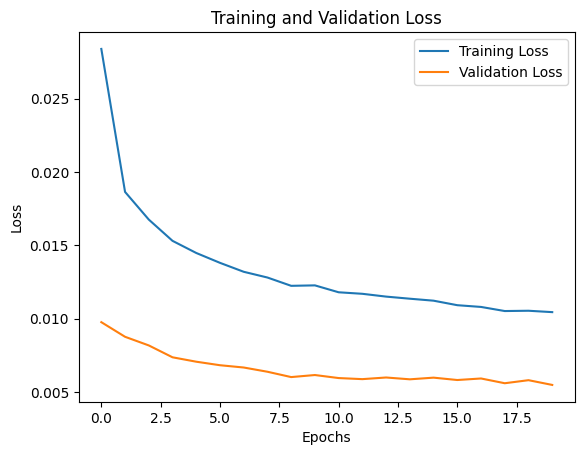

In [21]:
import pandas as pd
# convert the training history to a dataframe
history_df = pd.DataFrame(history.history)
# use Pandas native plot method
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Checking the accuracy of the model on test data:

In [23]:
loss, accuracy = model.evaluate(x_test, y_test_onehot, verbose=1)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9655 - loss: 0.0055
Test Loss: 0.0055
Test Accuracy: 0.9655


After training, we have initial training weight already, but to stop from start again over and over again, we save the model totally into a new file and use it again for production.

In [16]:
model.save("final_model/NNmodelver1.keras")
model.save("final_model/NNmodelver1.h5") 